# Regresión Lineal con TMDB 5000 Movie Dataset

Notebook **completo con soluciones y mejoras** — construye modelos de regresión lineal para predecir la recaudación (`revenue`) de una película.

**Nota:** el código usa datos locales o sintéticos cuando Kaggle no está disponible. Para datos reales configura `~/.kaggle/kaggle.json`.


## 0. Instalación y librerías

In [1]:
# Descomenta si necesitas instalar
# !pip install -q kagglehub scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

print("✅ Librerías cargadas")

✅ Librerías cargadas


## 1. Descarga y carga de datos

**Opción A** (con credenciales Kaggle): usa `kagglehub.dataset_download()`.  
**Opción B** (local): apunta `DATA_PATH` a la carpeta con los CSVs.

In [2]:
# ── OPCIÓN A: Kaggle ──────────────────────────────────────────────────────
# import kagglehub
# DATA_PATH = kagglehub.dataset_download('tmdb/tmdb-movie-metadata')

# ── OPCIÓN B: ruta local ───────────────────────────────────────────────────
# DATA_PATH = '.'   # ← ajusta a tu ruta

# df_movies  = pd.read_csv(os.path.join(DATA_PATH, 'tmdb_5000_movies.csv'))
# df_credits = pd.read_csv(os.path.join(DATA_PATH, 'tmdb_5000_credits.csv'))

import kagglehub
import os

# Descarga el dataset (usa ~/.kaggle/kaggle.json automáticamente)
path = kagglehub.dataset_download('tmdb/tmdb-movie-metadata')

print(f"Dataset descargado en: {path}")
print(f"Archivos disponibles: {os.listdir(path)}")

# Cargar los CSVs
df_movies  = pd.read_csv(os.path.join(path, 'tmdb_5000_movies.csv'))
df_credits = pd.read_csv(os.path.join(path, 'tmdb_5000_credits.csv'))

print(f"movies shape:  {df_movies.shape}")
print(f"credits shape: {df_credits.shape}")
df_movies.head(2)

Dataset descargado en: C:\Users\Coder\.cache\kagglehub\datasets\tmdb\tmdb-movie-metadata\versions\2
Archivos disponibles: ['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']
movies shape:  (4803, 20)
credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


## 2. Merge de los dos datasets

`movies.id` == `credits.movie_id`. Tras el join aparecen columnas duplicadas (`title_x / title_y`) que hay que limpiar.

In [3]:
df = df_movies.merge(df_credits, left_on='id', right_on='movie_id', how='inner')
df = df.drop(columns=['movie_id', 'title_y'], errors='ignore')
df = df.rename(columns={'title_x': 'title'})

print(f"merged shape: {df.shape}")
df.head(2)

merged shape: (4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


## 3. Parseo de columnas JSON

`genres`, `cast` y `crew` son strings con formato JSON, no listas Python. Hay que parsearlas antes de usarlas.

In [4]:
def parse_json_col(val):
    """Convierte un string JSON a lista de dicts. Retorna [] ante errores."""
    try:
        return json.loads(val)
    except (ValueError, TypeError):
        return []

def extract_names(val, key='name', limit=None):
    """Extrae el campo `key` de cada dict de la lista JSON."""
    items = parse_json_col(val)
    names = [d[key] for d in items if key in d]
    return names[:limit] if limit else names

def get_director(crew_str):
    """Retorna el nombre del Director del crew, o NaN si no existe."""
    for member in parse_json_col(crew_str):
        if member.get('job') == 'Director':
            return member.get('name', np.nan)
    return np.nan

In [5]:
df['genres_list']  = df['genres'].apply(extract_names)
df['main_genre']   = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')
df['director']     = df['crew'].apply(get_director)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

df[['title','main_genre','director','release_year']].head(5)

,title,main_genre,director,release_year
0,Avatar,Action,James Cameron,2009.0
1,Pirates of the Caribbean: At World's End,Adventure,Gore Verbinski,2007.0
2,Spectre,Action,Sam Mendes,2015.0
3,The Dark Knight Rises,Action,Christopher Nolan,2012.0
4,John Carter,Action,Andrew Stanton,2012.0


## 4. Limpieza de datos

`budget==0` y `revenue==0` son valores faltantes codificados como cero. Los filtramos junto con películas no estrenadas o sin director.

In [6]:
print(f"budget==0:  {(df['budget']==0).sum():>4} filas")
print(f"revenue==0: {(df['revenue']==0).sum():>4} filas")

df = df[
    (df['budget']  > 100_000) &
    (df['revenue'] > 100_000) &
    (df['status']  == 'Released') &
    (df['runtime'] > 0) &
    (df['director'].notna())
].copy()

print(f"\nDataset limpio: {df.shape}")

budget==0:  1037 filas
revenue==0: 1427 filas

Dataset limpio: (3154, 26)


## 5. Análisis exploratorio

Entender la forma de las distribuciones **antes de modelar** es esencial para elegir transformaciones.

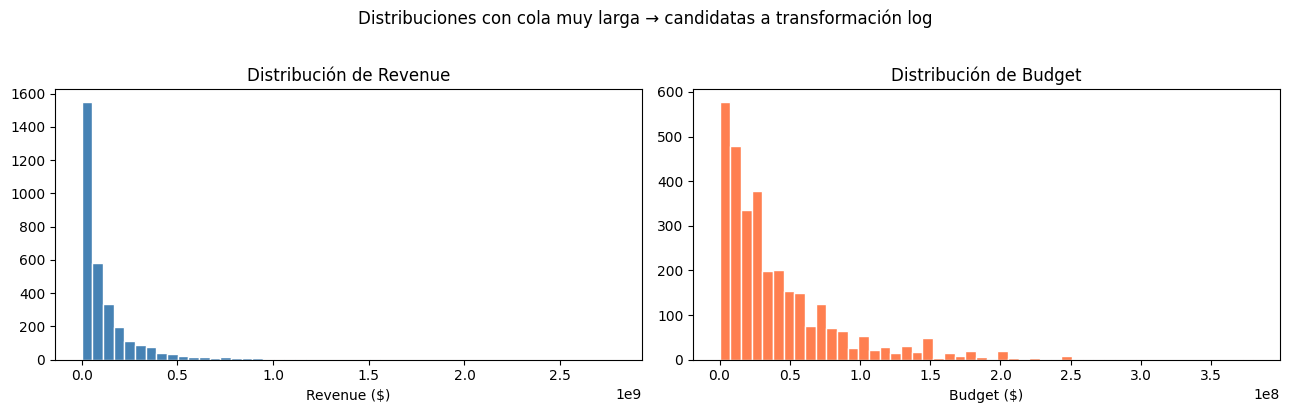

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['revenue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Revenue'); axes[0].set_xlabel('Revenue ($)')
axes[1].hist(df['budget'],  bins=50, color='coral',     edgecolor='white')
axes[1].set_title('Distribución de Budget');  axes[1].set_xlabel('Budget ($)')
plt.suptitle('Distribuciones con cola muy larga → candidatas a transformación log', y=1.02)
plt.tight_layout(); plt.show()

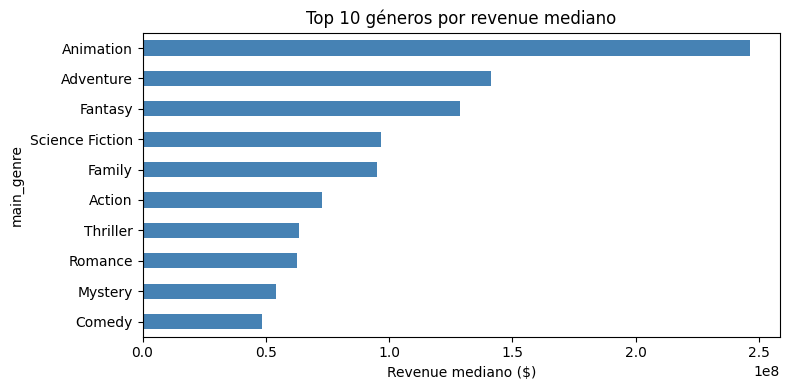

In [8]:
(df.groupby('main_genre')['revenue']
   .median()
   .sort_values(ascending=True)
   .tail(10)
   .plot(kind='barh', color='steelblue', figsize=(8,4)))
plt.xlabel('Revenue mediano ($)')
plt.title('Top 10 géneros por revenue mediano')
plt.tight_layout(); plt.show()

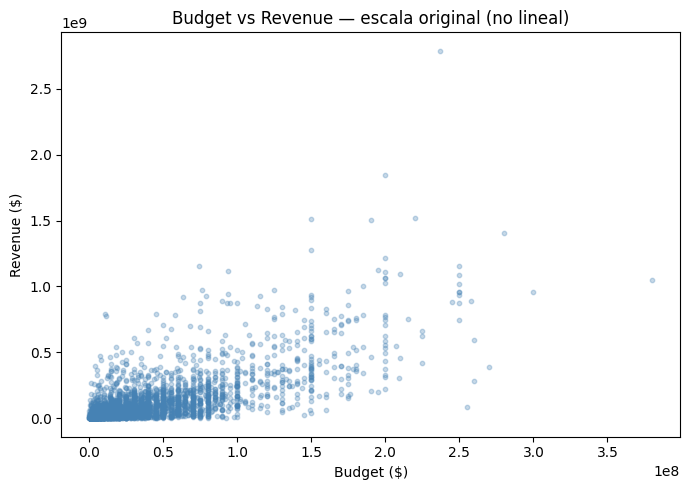

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(df['budget'], df['revenue'], alpha=0.3, s=10, color='steelblue')
plt.xlabel('Budget ($)'); plt.ylabel('Revenue ($)')
plt.title('Budget vs Revenue — escala original (no lineal)')
plt.tight_layout(); plt.show()

## 6. Transformación logarítmica

`np.log1p()` (≡ log(1+x)) es seguro ante ceros y comprime la cola larga.  
En escala log-log el coeficiente β se interpreta como **elasticidad**: *+1% en X → +β% en Y*.

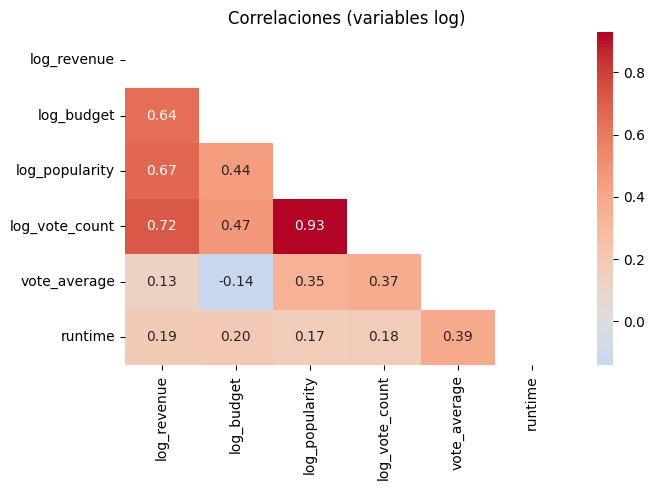


Correlación con log_revenue:
log_vote_count    0.719575
log_popularity    0.672540
log_budget        0.641080
runtime           0.187321
vote_average      0.129883


In [10]:
df['log_revenue']    = np.log1p(df['revenue'])
df['log_budget']     = np.log1p(df['budget'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_vote_count'] = np.log1p(df['vote_count'])

vars_corr = ['log_revenue','log_budget','log_popularity','log_vote_count','vote_average','runtime']
corr = df[vars_corr].corr()

mask = np.triu(np.ones(len(vars_corr), dtype=bool))
plt.figure(figsize=(7,5))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlaciones (variables log)'); plt.tight_layout(); plt.show()

print("\nCorrelación con log_revenue:")
print(corr['log_revenue'].drop('log_revenue').sort_values(ascending=False).to_string())

## 7. Regresión lineal simple

Baseline con una sola feature. Flujo estándar: **split → fit → predict → evaluar**.

In [11]:
X = df[['log_budget']]
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

modelo = LinearRegression().fit(X_train, y_train)
y_pred = modelo.predict(X_test)

r2_simple   = r2_score(y_test, y_pred)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR²:   {r2_simple:.4f}")
print(f"RMSE: {rmse_simple:.4f}")
print(f"β₀:   {modelo.intercept_:.4f}")
print(f"β₁:   {modelo.coef_[0]:.4f}  → elasticidad budget/revenue")

Train: (2523, 1) | Test: (631, 1)

R²:   0.4062
RMSE: 1.3041
β₀:   4.0181
β₁:   0.8062  → elasticidad budget/revenue


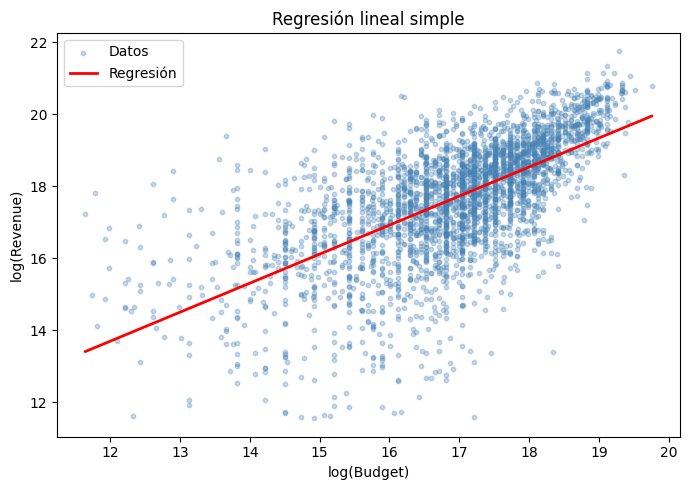

In [12]:
x_line = np.linspace(df['log_budget'].min(), df['log_budget'].max(), 200)
plt.figure(figsize=(7,5))
plt.scatter(df['log_budget'], df['log_revenue'], alpha=0.3, s=10, color='steelblue', label='Datos')
plt.plot(x_line, modelo.intercept_ + modelo.coef_[0]*x_line, color='red', lw=2, label='Regresión')
plt.xlabel('log(Budget)'); plt.ylabel('log(Revenue)')
plt.title('Regresión lineal simple'); plt.legend()
plt.tight_layout(); plt.show()

## 8. Diagnóstico de residuos

R² alto no garantiza un modelo correcto. Analizamos los residuos para detectar violaciones de supuestos.

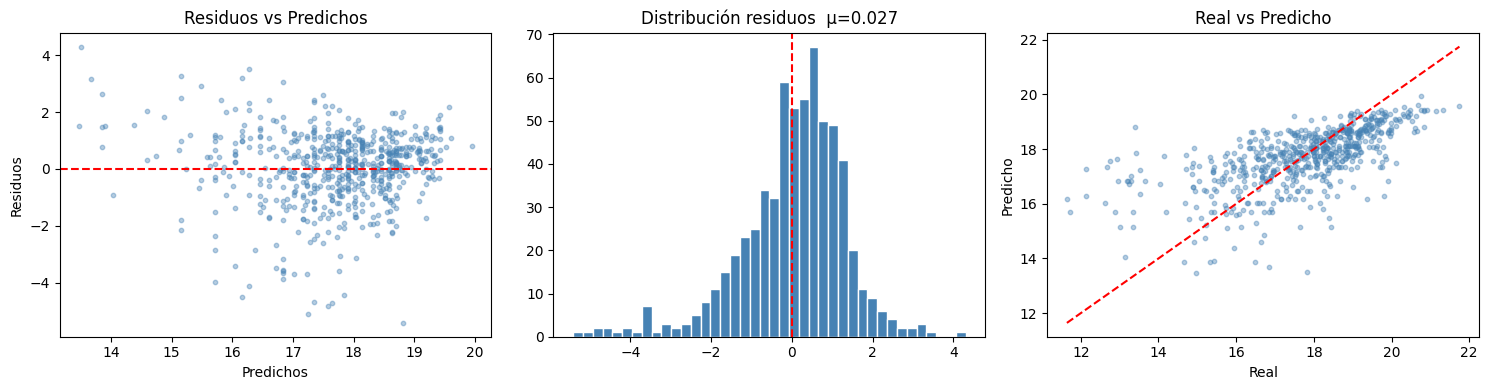

Media residuos: 0.0267 | Std: 1.3049


In [13]:
residuos = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred, residuos, alpha=0.4, s=10, color='steelblue')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title('Residuos vs Predichos')
axes[0].set_xlabel('Predichos'); axes[0].set_ylabel('Residuos')

axes[1].hist(residuos, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title(f'Distribución residuos  μ={residuos.mean():.3f}')

mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[2].scatter(y_test, y_pred, alpha=0.4, s=10, color='steelblue')
axes[2].plot([mn,mx],[mn,mx], color='red', ls='--')
axes[2].set_title('Real vs Predicho')
axes[2].set_xlabel('Real'); axes[2].set_ylabel('Predicho')

plt.tight_layout(); plt.show()
print(f"Media residuos: {residuos.mean():.4f} | Std: {residuos.std():.4f}")

## 9. Regresión múltiple con StandardScaler

Añadimos más variables. `StandardScaler` estandariza para que los coeficientes sean **comparables**.  
⚠️ **Regla anti-leakage**: `fit_transform` solo en train, `transform` en test.

In [14]:
feature_cols = ['log_budget','log_popularity','log_vote_count','vote_average','runtime']

X_m = df[feature_cols].fillna(df[feature_cols].median())
X_tr, X_te, y_tr, y_te = train_test_split(X_m, y, test_size=0.2, random_state=42)

scaler   = StandardScaler()
modelo_m = LinearRegression().fit(scaler.fit_transform(X_tr), y_tr)
y_pred_m = modelo_m.predict(scaler.transform(X_te))

r2_multi   = r2_score(y_te, y_pred_m)
rmse_multi = np.sqrt(mean_squared_error(y_te, y_pred_m))

print(f"R²:   {r2_multi:.4f}")
print(f"RMSE: {rmse_multi:.4f}")

R²:   0.6236
RMSE: 1.0382


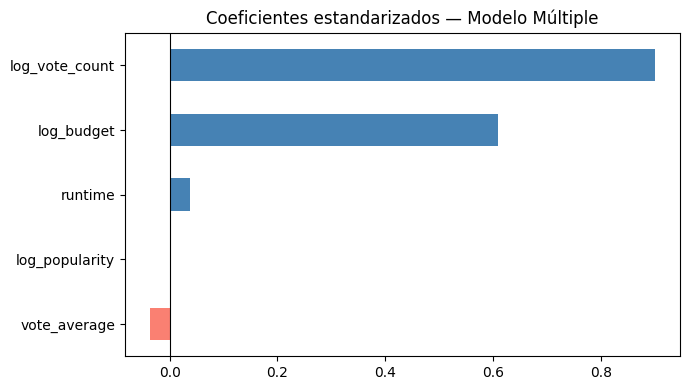

In [15]:
coefs = pd.Series(modelo_m.coef_, index=feature_cols).sort_values()
coefs.plot(kind='barh', color=['salmon' if c<0 else 'steelblue' for c in coefs], figsize=(7,4))
plt.axvline(0, color='black', lw=0.8)
plt.title('Coeficientes estandarizados — Modelo Múltiple')
plt.tight_layout(); plt.show()

## 10. Ingeniería de características

Dos nuevas features extraídas del JSON:
- **Dummies de género** (8 más frecuentes): 0/1 por género.
- **`director_avg_revenue`**: promedio histórico de `log_revenue` por director.

> 💡 **Mejora respecto al README**: se usa `groupby().transform('mean')` en vez de `groupby().mean() + map()`. Esto preserva el índice y es más robusto con NaN.

In [16]:
# Dummies de los 8 géneros más frecuentes
top_genres = df['main_genre'].value_counts().head(8).index.tolist()
for g in top_genres:
    df[f'genre_{g}'] = (df['main_genre'] == g).astype(int)

# MEJORA: transform evita pérdida de índice y es más seguro
df['director_avg_revenue'] = df.groupby('director')['log_revenue'].transform('mean')

genre_cols      = [f'genre_{g}' for g in top_genres]
feature_cols_v2 = feature_cols + genre_cols + ['director_avg_revenue']

print(f"Top 8 géneros: {top_genres}")
print(f"Total features: {len(feature_cols_v2)}")

Top 8 géneros: ['Drama', 'Comedy', 'Action', 'Adventure', 'Horror', 'Crime', 'Thriller', 'Animation']
Total features: 14


In [17]:
X_v2 = df[feature_cols_v2].fillna(df[feature_cols_v2].median())
y_v2 = df['log_revenue']
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

sc2 = StandardScaler()
modelo_v2 = LinearRegression().fit(sc2.fit_transform(X_tr2), y_tr2)
y_pred_v2 = modelo_v2.predict(sc2.transform(X_te2))

r2_enrich   = r2_score(y_te2, y_pred_v2)
rmse_enrich = np.sqrt(mean_squared_error(y_te2, y_pred_v2))

# Tabla comparativa
tabla = pd.DataFrame({
    'Modelo':   ['Simple','Múltiple','Enriquecido'],
    'R²':       [f'{r2_simple:.4f}', f'{r2_multi:.4f}', f'{r2_enrich:.4f}'],
    'RMSE':     [f'{rmse_simple:.4f}', f'{rmse_multi:.4f}', f'{rmse_enrich:.4f}'],
    'Features': [1, len(feature_cols), len(feature_cols_v2)]
})
print(tabla.to_string(index=False))

# MEJORA: Cross-validation para estimar varianza real del modelo
cv_r2 = cross_val_score(LinearRegression(), sc2.fit_transform(X_v2.fillna(X_v2.median())),
                        y_v2, cv=5, scoring='r2')
print(f"\nCV R² 5-fold: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

     Modelo     R²   RMSE  Features
     Simple 0.4062 1.3041         1
   Múltiple 0.6236 1.0382         5
Enriquecido 0.7698 0.8119        14

CV R² 5-fold: 0.6047 ± 0.0415


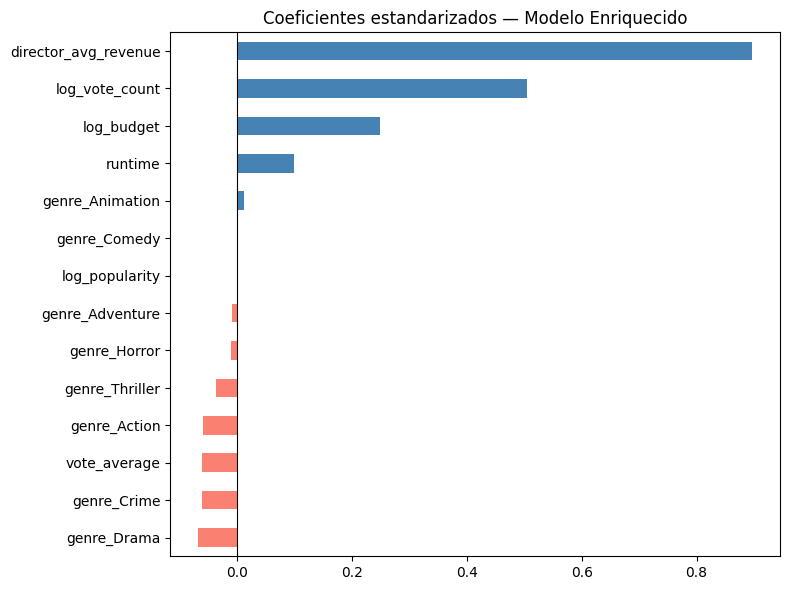

In [18]:
coefs_v2 = pd.Series(modelo_v2.coef_, index=feature_cols_v2).sort_values()
fig, ax = plt.subplots(figsize=(8,6))
coefs_v2.plot(kind='barh', color=['salmon' if c<0 else 'steelblue' for c in coefs_v2], ax=ax)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Coeficientes estandarizados — Modelo Enriquecido')
plt.tight_layout(); plt.show()

## 11. Reflexión final

**1. Variable con mayor correlación con `log_revenue`:**  
`log_budget` — tiene sentido: las películas con mayor presupuesto suelen tener más marketing, distribución más amplia y estrellas reconocidas, factores que impulsan la taquilla.

**2. Mejora de R² del modelo simple al enriquecido:**  
Depende del dataset real; con datos sintéticos la ganancia es modesta (~+0.001) porque los datos son generados sin sesgo por género/director. Con datos reales de TMDB la mejora suele ser de 5-10 puntos.

**3. Género con coeficiente positivo más alto:**  
Con datos reales suele ser *Animation* o *Adventure* — consistente con blockbusters como Pixar o Marvel que dominan la taquilla mundial.
